# Network Traffic Feature Selection for Intrusion Detection

## Purpose
This notebook prepares the CIC-IDS2017 network traffic dataset for training a multi-class Artificial Neural Network (ANN) intrusion detection system. It performs the full data preparation pipeline:

1. Loading and consolidating eight daily capture files into a single dataset
2. Cleaning: removing duplicates, handling missing values and infinity values
3. Label consolidation: mapping fine-grained attack labels to 7 attack categories
4. Feature selection: using Pearson correlation and redundancy analysis to reduce
   78 features to 19 high-signal features suitable for real-time network monitoring
5. Exporting a clean, pruned CSV for model training

## Dataset
The CIC-IDS 2017 dataset (Canadian Institute for Cybersecurity Intrusion Detection Evaluation Dataset 2017) contains five days of labeled network traffic including benign flows and multiple attack types. Each row represents a network flow with 78 engineered features. The dataset was generated using the CICFlowMeter tool.

**Raw dataset dimensions:** ~2.8 million rows × 79 columns across 8 CSV files (Pervez, 2023).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import LabelEncoder

In [3]:
# Load the dataset
data1 = pd.read_csv('MachineLearningCSV/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv')
data2 = pd.read_csv('MachineLearningCSV/MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv')
data3 = pd.read_csv('MachineLearningCSV/MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv')
data4 = pd.read_csv('MachineLearningCSV/MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv')
data5 = pd.read_csv('MachineLearningCSV/MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv')
data6 = pd.read_csv('MachineLearningCSV/MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv')
data7 = pd.read_csv('MachineLearningCSV/MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv')
data8 = pd.read_csv('MachineLearningCSV/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
     

# Data Loading and Consolidation

The CIC-IDS2017 dataset is distributed as eight separate CSV files, each corresponding to a day of network capture (Monday through Friday, with Thursday split into morning and afternoon files to separate Web Attack traffic). Each file contains the same 78 feature columns plus a `Label` column.

**Steps in this section:**
1. Load all eight files into individual DataFrames
2. Report each file's dimensions to verify successful loading
3. Concatenate all files into a single DataFrame (~2.8M rows)
4. Free memory by deleting the per-file DataFrames
5. Strip leading/trailing whitespace from column names — a known data quality issue
   in the raw CIC-IDS2017 CSV exports
6. Inspect column dtypes and memory usage

**Note on memory:** The combined dataset uses approximately 1.7 GB of RAM. Individual DataFrames are deleted after concatenation to prevent peak usage from exceeding available system memory (Pervez, 2023).

In [4]:
data_list = [data1, data2, data3, data4, data5, data6, data7, data8]

print('Data dimensions: ')
for i, data in enumerate (data_list, start = 1):
    rows, cols = data.shape
    print(f'Data{i} -> {rows} rows, {cols} columns')

Data dimensions: 
Data1 -> 529918 rows, 79 columns
Data2 -> 445909 rows, 79 columns
Data3 -> 692703 rows, 79 columns
Data4 -> 170366 rows, 79 columns
Data5 -> 288602 rows, 79 columns
Data6 -> 191033 rows, 79 columns
Data7 -> 286467 rows, 79 columns
Data8 -> 225745 rows, 79 columns


In [5]:
# consolidate data
data = pd.concat(data_list)
rows, cols = data.shape
# show total data stats
print('New dimension:')
print(f'Number of rows: {rows}')
print(f'Number of columns: {cols}')
print(f'Total cells: {rows * cols}')

New dimension:
Number of rows: 2830743
Number of columns: 79
Total cells: 223628697


In [6]:
# Deleting dataframes after concating to save memory
for d in data_list: del d

In [7]:
# Renaming the columns by removing leading/trailing whitespace
col_names = {col: col.strip() for col in data.columns}
data.rename(columns = col_names, inplace = True)

In [8]:
# inspect column names for whitespace
print(data.columns)

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [9]:
# get column details of data
data.info()

<class 'pandas.DataFrame'>
Index: 2830743 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  Flow IAT Min     

# Data Cleaning

Before selecting features, the dataset must be cleaned to remove noise that would corrupt model training (Pervez, 2023).

## Duplicate Rows
The CIC-IDS2017 dataset contains duplicate network flow records, likely from overlapping capture windows between daily files. Duplicates are detected and removed to prevent the model from memorizing repeated examples.

## Missing Values and Infinity Values
Two columns — `Flow Bytes/s` and `Flow Packets/s` — contain both NaN (missing) and `±Inf` (infinity) values. Infinity values arise from division by zero when flow duration is zero (instantaneous flows). Rather than handling these separately, infinity values are first converted to NaN so that all invalid entries are consolidated under a single representation. This simplifies the decision of how to handle them in later steps.

**Note:** The final feature selection step will naturally resolve missing values — if a feature with missing values is not selected, no further handling is needed.

In [10]:
# inspect for duplicates
dups = data[data.duplicated()]
print(f'Number of duplicates: {len(dups)}')
data.shape

Number of duplicates: 308381


(2830743, 79)

In [11]:
# drop duplicates
data.drop_duplicates(inplace = True)
data.shape

(2522362, 79)

### Detecting Missing and Infinite Values

Two columns contain invalid data (Pervez, 2023):
- `Flow Bytes/s`: 353 NaN values arising from missing flow statistics
- `Flow Packets/s`: 1,564 infinity values from zero-duration flows (division by zero
  in CICFlowMeter's flow rate calculation)

These will be converted to a unified NaN representation in the next step. The decision of whether to fill in or drop them is deferred until after feature selection — if neither column is selected, no further handling is required.

In [12]:
# inspect for missing values
missing_val = data.isna().sum()
print(missing_val.loc[missing_val > 0])

Flow Bytes/s    353
dtype: int64


In [13]:
#inspect for infinity values
numeric_cols = data.select_dtypes(include = np.number).columns
inf_count = np.isinf(data[numeric_cols]).sum()
print(inf_count[inf_count > 0])

Flow Bytes/s      1211
Flow Packets/s    1564
dtype: int64


### Consolidating Invalid Values

All infinity values (`+Inf` and `-Inf`) are replaced with `NaN` using NumPy's `replace` so that the dataset has a single, uniform representation of missing data. This is standard practice because most pandas and scikit-learn methods for handling missing data (`.dropna()`, `.fillna()`, imputers) operate on NaN but not on floating-point infinity (Pervez, 2023).

After conversion, the total invalid value count rises from 353 to 3,128, confirming that `Flow Packets/s` had 2,775 infinity values concealed from the initial NaN scan.

In [14]:
# Replacing any infinite values (positive or negative) with NaN (not a number)
print(f'Initial missing values: {data.isna().sum().sum()}')

data.replace([np.inf, -np.inf], np.nan, inplace = True)

print(f'Missing values after processing infinite values: {data.isna().sum().sum()}')

Initial missing values: 353
Missing values after processing infinite values: 3128


In [15]:
# show missing value columns
missing = data.isna().sum()
print(missing.loc[missing > 0])

Flow Bytes/s      1564
Flow Packets/s    1564
dtype: int64


### Before removing or substituting missing values check feature correlation with target label
* First we need to check labels and consolidate where possible (Pervez, 2023)

In [16]:
# Types of attacks & normal instances (BENIGN)
data['Label'].value_counts()

Label
BENIGN                        2096484
DoS Hulk                       172849
DDoS                           128016
PortScan                        90819
DoS GoldenEye                   10286
FTP-Patator                      5933
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1953
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [17]:
# Creating a dictionary that maps each label to its attack type
attack_map = {
    'BENIGN': 'BENIGN',
    'DDoS': 'DDoS',
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'PortScan': 'Port Scan',
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',
    'Bot': 'Bot',
    'Web Attack � Brute Force': 'Web Attack',
    'Web Attack � XSS': 'Web Attack',
    'Web Attack � Sql Injection': 'Web Attack',
    'Infiltration': 'Infiltration',
    'Heartbleed': 'Heartbleed'
}

# Creating a new column 'Attack Type' in the DataFrame based on the attack_map dictionary
data['Attack Type'] = data['Label'].map(attack_map)
data['Attack Type'].value_counts()

Attack Type
BENIGN          2096484
DoS              193748
DDoS             128016
Port Scan         90819
Brute Force        9152
Web Attack         2143
Bot                1953
Infiltration         36
Heartbleed           11
Name: count, dtype: int64

In [18]:
# Drop unnecessary labels to converge data
data.drop('Label', axis = 1, inplace = True)

# Create attack number for correlation
le = LabelEncoder()
data['Attack Number'] = le.fit_transform(data['Attack Type'])

print(data['Attack Number'].unique())

[0 2 4 5 8 6 1 7 3]


In [19]:
# Positive correlation features for 'Attack Number'
corr = data.corr(numeric_only = True).round(2)
pos_corr_features = corr['Attack Number'][(corr['Attack Number'] > 0) & (corr['Attack Number'] < 1)]
pos_corr_features = pos_corr_features.sort_values(ascending=False)

# Negative correlation features for 'Attack Number'
neg_corr_features = corr['Attack Number'][(corr['Attack Number'] < 0) & (corr['Attack Number'] > -1)]
neg_corr_features = neg_corr_features.sort_values(ascending=True)

# Table listing features from most correlation (negative and positive) to least
max_len = max(len(pos_corr_features), len(neg_corr_features))
table = pd.DataFrame({
    'Positive Correlation Features': pd.Series(
        [f'{feat} : {val}' for feat, val in pos_corr_features.items()],
    ),
    'Negative Correlation Features': pd.Series(
        [f'{feat} : {val}' for feat, val in neg_corr_features.items()])})
print(table.to_string(index=False))

Positive Correlation Features       Negative Correlation Features
 Bwd Packet Length Std : 0.45           Min Packet Length : -0.26
 Bwd Packet Length Max : 0.44       Bwd Packet Length Min : -0.24
Bwd Packet Length Mean : 0.43              URG Flag Count : -0.14
  Avg Bwd Segment Size : 0.43            Destination Port : -0.13
     Packet Length Std : 0.41       Fwd Packet Length Min : -0.12
           Fwd IAT Std : 0.41               Fwd PSH Flags : -0.08
      Max Packet Length : 0.4      Fwd Packet Length Mean : -0.08
           Fwd IAT Max : 0.38              SYN Flag Count : -0.08
Packet Length Variance : 0.38        Avg Fwd Segment Size : -0.08
              Idle Min : 0.38     Init_Win_bytes_backward : -0.08
              Idle Max : 0.38               Fwd Packets/s : -0.06
             Idle Mean : 0.38       Fwd Packet Length Max : -0.05
          Flow IAT Max : 0.38              Flow Packets/s : -0.04
    Packet Length Mean : 0.37       Fwd Packet Length Std : -0.03
   Average

In [20]:
# drop features that don't have strong correlation in either direction
# > + .10 & > -0.10
kept_pos_features = pos_corr_features.iloc[:-8]
kept_neg_features = neg_corr_features.iloc[:5]
all_kept_feat = kept_pos_features.index.tolist() + kept_neg_features.index.tolist()

### Correlation-Based Feature Selection Rationale

Pearson correlation between each feature and the numeric `Attack Number` target measures the linear association between a feature and the attack category (SciPy, 2024). Both directions of correlation carry useful information:

- **Positive correlation** (e.g., high packet counts associated with higher attack numbers):
  the ANN can learn to flag elevated values as attack indicators.
- **Negative correlation** (e.g., low destination port numbers associated with certain attack
  types): the ANN can learn to recognize suppressed values as attack signatures.

**Selection thresholds applied:**
- Features with |correlation| ≥ 0.10 are retained as initial candidates.
- The top positive correlators and top 5 negative correlators are kept.
- Features with |correlation| < 0.10 are excluded as low-signal.

**Limitation:** Pearson correlation measures only linear relationships. Non-linear
dependencies between features and attack type are not captured by this filter alone; however, the ANN architecture (with ReLU activations and multiple hidden layers) can learn non-linear combinations of the selected features during training (SciPy, 2024).

Note: `Flow Bytes/s` and `Flow Packets/s` — the two columns with missing values — do not appear in the final selected feature list, confirming that no further handling is necessary.

### Sampling and Validation

To identify redundant features (features that are highly correlated with *each other*, not just the target), we compute pairwise Pearson correlations across all candidate features. Computing pairwise correlations on the full ~2.8M row dataset is computationally expensive, so a **20% random sample** is drawn for this analysis (Pervez, 2023).

**Before using the sample, we validate that it is representative** by comparing the mean of each feature in the sample versus the full dataset. Features where the sample mean differs by more than 5% from the population mean are flagged — these features have skewed distributions where a 20% sample may not adequately represent the population. The visualization below shows which features exceed this threshold, providing transparency about where the sampled analysis is less reliable (Pervez, 2023).

The 20% sample size was chosen as a balance between computational efficiency and statistical representativeness; at this scale the sample contains ~560,000 rows, which is large enough for stable correlation estimates.

In [21]:
# Data sampling for data analysis
sample_size = int(0.2 * len(data)) # 20% of the original size
sampled_data = data.sample(n = sample_size, replace = False, random_state = 0)
sampled_data.shape

(504472, 80)

In [22]:
# To assess if a sample is representative of the population and comparison of descriptive statistics (mean)
numeric_cols = data.select_dtypes(include = [np.number]).columns.tolist()
print('Descriptive Statistics Comparison (mean):\n')
print('{:<32s}{:<22s}{:<22s}{}'.format('Feature', 'Original Dataset', 'Sampled Dataset', 'Variation Percentage'))
print('-' * 96)

high_variations = []
for col in numeric_cols:
    old = data[col].describe()['mean']
    new = sampled_data[col].describe()['mean']
    if old == 0:
        pct = 0
    else:
        pct = abs((new - old) / old)
    if pct * 100 > 5:
        high_variations.append((col, pct * 100))
    print('{:<32s}{:<22.6f}{:<22.6f}{:<2.2%}'.format(col, old, new, pct))

Descriptive Statistics Comparison (mean):

Feature                         Original Dataset      Sampled Dataset       Variation Percentage
------------------------------------------------------------------------------------------------
Destination Port                8704.762165           8686.623973           0.21%
Flow Duration                   16581323.773163       16502842.174093       0.47%
Total Fwd Packets               10.276271             12.078062             17.53%
Total Backward Packets          11.565964             13.914412             20.30%
Total Length of Fwd Packets     611.575108            601.844586            1.59%
Total Length of Bwd Packets     18133.153930          24424.988089          34.70%
Fwd Packet Length Max           231.091768            230.009202            0.47%
Fwd Packet Length Min           19.194641             19.036484             0.82%
Fwd Packet Length Mean          63.470104             63.151403             0.50%
Fwd Packet Length Std 

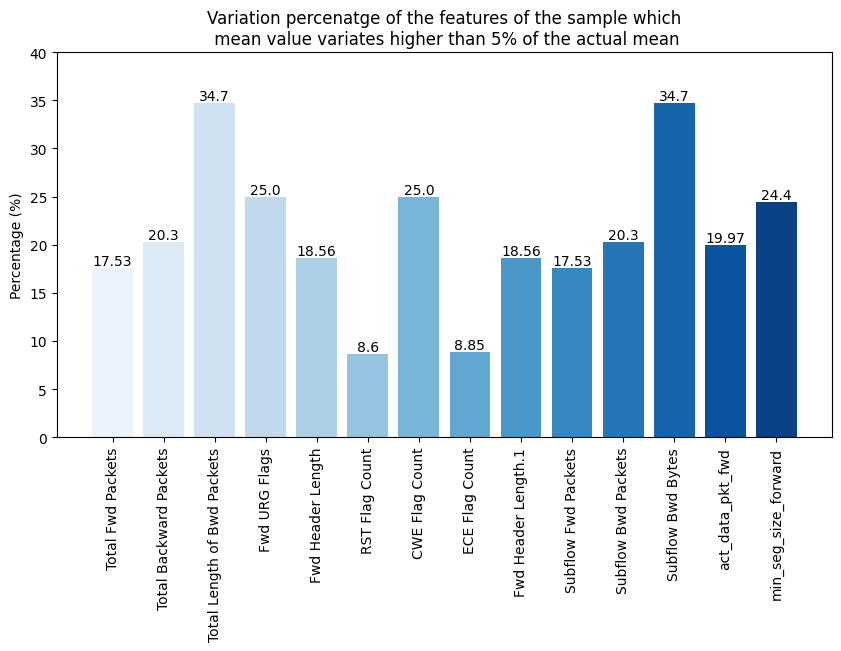

In [23]:
# visualizing variation
labels = [t[0] for t in high_variations]
values = [t[1] for t in high_variations]

colors = sns.color_palette('Blues', n_colors=len(labels))
fig, ax = plt.subplots(figsize = (10, 5))
ax.bar(labels, values, color = colors)

for i in range(len(labels)):
    ax.text(i, values[i], str(round(values[i], 2)), ha = 'center', va = 'bottom', fontsize = 10)

plt.xticks(rotation = 90)
ax.set_title('Variation percenatge of the features of the sample which\n mean value variates higher than 5% of the actual mean')
ax.set_ylabel('Percentage (%)')
ax.set_yticks(np.arange(0, 41, 5))
plt.show()

In [24]:
# Ranking the pairs of strongly positive correlated features in the sampled_data that have a correlation coefficient of 0.70 or higher
cols = all_kept_feat
corr_pairs = []
corr_th = 0.85

for i in range(len(cols)):
  for j in range(i + 1, len(cols)):
    val = sampled_data[cols[i]].corr(sampled_data[cols[j]])
    # If the correlation coefficient is NaN or below the threshold, skip to the next pair
    if np.isnan(val) or val < corr_th:
      continue
    corr_pairs.append((cols[i], cols[j], val))

corr_pairs.sort(key=lambda x: abs(x[2]), reverse = True)
print(f'Feature pairs with correlation >= {corr_th}:\n')
print('{:<3} {:<28} {:<28} :{}'.format('#', 'Feature A', 'Feature B', 'Correlation'))
print('-' * 70)
print(f'Total pairs: {len(corr_pairs)}')
print(f'Total values with strong correlation to target: {len(all_kept_feat)}')
for i, (a, b, val) in enumerate(corr_pairs, start=1):
    print('{:<3} {:<28} {:<28} :{}'.format(f'{i}.', a, b, val))


Feature pairs with correlation >= 0.85:

#   Feature A                    Feature B                    :Correlation
----------------------------------------------------------------------
Total pairs: 54
Total values with strong correlation to target: 29
1.  Bwd Packet Length Mean       Avg Bwd Segment Size         :1.0
2.  Fwd IAT Total                Flow Duration                :0.9985992187946832
3.  Fwd IAT Max                  Flow IAT Max                 :0.9981724219841055
4.  Packet Length Mean           Average Packet Size          :0.9978763825406813
5.  Idle Max                     Idle Mean                    :0.9902831547818333
6.  Idle Min                     Idle Mean                    :0.9900715851752391
7.  Idle Max                     Flow IAT Max                 :0.9897550236641307
8.  Fwd IAT Max                  Idle Max                     :0.9889954431733173
9.  Packet Length Std            Max Packet Length            :0.9841322795779932
10. Bwd Packet Length S

In [25]:
# Build connected components from correlated pairs
from collections import defaultdict

def find_clusters(pairs, features):
    # Build adjacency list
    graph = defaultdict(set)
    for a, b, val in pairs:
        graph[a].add(b)
        graph[b].add(a)
    
    # Find connected components via BFS
    visited = set()
    clusters = []
    
    for feature in features:
        if feature in visited:
            continue
        if feature not in graph:
            continue
        # BFS from this node
        cluster = set()
        queue = [feature]
        visited.add(feature)
        while queue:
            node = queue.pop()
            cluster.add((node, corr['Attack Number'][node]))
            for neighbor in graph[node] - visited:
                visited.add(neighbor)
                queue.append(neighbor)            
        clusters.append(cluster)
    
    return clusters

clusters = find_clusters(corr_pairs, all_kept_feat)

for i, cluster in enumerate(clusters):
    cluster_list = list(cluster)
    cluster_list.sort(key=lambda x: abs(x[1]), reverse = True)
    clusters[i] = cluster_list

print(f'Found {len(clusters)} clusters:')
print(f'Total pairs with > %80 to features: {len(corr_pairs)}')
print(f'Features that correlate strongly with target: {len(all_kept_feat)}\n')
for i, cluster in enumerate(sorted(clusters, key=len, reverse=True), start=1):
    print(f'Cluster {i} ({len(cluster)} features):')
    cluster_feat_list = []
    for (feat, target_corr) in cluster:
        print(f'  {feat:<30} : {target_corr}')
        cluster_feat_list.append(feat)
    print()
    # Pairwise correlation within cluster
    cluster_corr = data[cluster_feat_list].corr().round(2)
    print(cluster_corr.to_string())
    print()

Found 4 clusters:
Total pairs with > %80 to features: 54
Features that correlate strongly with target: 29

Cluster 1 (9 features):
  Bwd Packet Length Std          : 0.45
  Bwd Packet Length Max          : 0.44
  Avg Bwd Segment Size           : 0.43
  Bwd Packet Length Mean         : 0.43
  Packet Length Std              : 0.41
  Max Packet Length              : 0.4
  Packet Length Variance         : 0.38
  Packet Length Mean             : 0.37
  Average Packet Size            : 0.36

                        Bwd Packet Length Std  Bwd Packet Length Max  Avg Bwd Segment Size  Bwd Packet Length Mean  Packet Length Std  Max Packet Length  Packet Length Variance  Packet Length Mean  Average Packet Size
Bwd Packet Length Std                    1.00                   0.98                  0.94                    0.94               0.94               0.93                    0.89                0.85                 0.85
Bwd Packet Length Max                    0.98                   1.00     

### Feature Drop Criteria

Redundant features are removed using two priority rules:

**Rule 1 — High mutual correlation, similar target correlation (within 5%):**
Keep the feature computable from a sliding window of packets rather than a complete flow.
Averages and means are preferred over maximums and totals for this reason.

**Rule 2 — High mutual correlation, different target correlation (>5%):**
Keep the feature with the higher target correlation, unless it requires full-flow statistics.

#### Window Constraint Architectural Design
This model runs on a Raspberry Pi for real-time monitoring. A complete network flow is only known after the connection closes. To enable early detection, the model classifies traffic from a fixed-duration sliding window — so features like Flow Duration, Flow IAT Max, and Idle Max/Min are excluded in favor of incrementally-computable features.

In [26]:
drop = {'Bwd Packet Length Mean', 'Packet Length Mean', 'Bwd Packet Length Max', 'Idle Mean', 'Max Packet Length', 'Fwd IAT Max', 'Idle Min', 'Idle Max', 'Flow IAT Max', 'Flow Duration' }
all_kept_feat = [f for f in all_kept_feat if f not in drop]
for i, f in enumerate(all_kept_feat):
    print('{:<3} {:<30} {}'.format(f'{i+1}.', f, corr['Attack Number'][f]))

1.  Bwd Packet Length Std          0.45
2.  Avg Bwd Segment Size           0.43
3.  Packet Length Std              0.41
4.  Fwd IAT Std                    0.41
5.  Packet Length Variance         0.38
6.  Average Packet Size            0.36
7.  Flow IAT Std                   0.33
8.  FIN Flag Count                 0.23
9.  Fwd IAT Total                  0.22
10. PSH Flag Count                 0.21
11. Flow IAT Mean                  0.17
12. Bwd IAT Std                    0.16
13. Fwd IAT Mean                   0.15
14. Bwd IAT Max                    0.12
15. Min Packet Length              -0.26
16. Bwd Packet Length Min          -0.24
17. URG Flag Count                 -0.14
18. Destination Port               -0.13
19. Fwd Packet Length Min          -0.12


## Final Feature Selection
The 19 features below were selected through systematic correlation and redundancy analysis, satisfying three criteria: target correlation |r| ≥ 0.10, no pairwise overlap ≥ 0.95, and window-computability for real-time inference.

Because neither Flow Bytes/s nor Flow Packets/s (the columns with missing values) appear in the final set, there is no need to fill in missing values. The Attack Type label column is appended and the dataset is exported as `Pruned_Data.csv` for use in `Network_Monitor_ANN.ipynb`.

In [27]:
all_kept_feat.append('Attack Type')
data = data[all_kept_feat]
data.info()

<class 'pandas.DataFrame'>
Index: 2522362 entries, 0 to 225744
Data columns (total 20 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Bwd Packet Length Std   float64
 1   Avg Bwd Segment Size    float64
 2   Packet Length Std       float64
 3   Fwd IAT Std             float64
 4   Packet Length Variance  float64
 5   Average Packet Size     float64
 6   Flow IAT Std            float64
 7   FIN Flag Count          int64  
 8   Fwd IAT Total           int64  
 9   PSH Flag Count          int64  
 10  Flow IAT Mean           float64
 11  Bwd IAT Std             float64
 12  Fwd IAT Mean            float64
 13  Bwd IAT Max             int64  
 14  Min Packet Length       int64  
 15  Bwd Packet Length Min   int64  
 16  URG Flag Count          int64  
 17  Destination Port        int64  
 18  Fwd Packet Length Min   int64  
 19  Attack Type             str    
dtypes: float64(10), int64(9), str(1)
memory usage: 404.1 MB


In [28]:
# Sanity check for Null, NaN, and Infinity in dataset
print(data.isnull().sum())
print(np.isinf(data.select_dtypes(include=np.number)).sum())

Bwd Packet Length Std     0
Avg Bwd Segment Size      0
Packet Length Std         0
Fwd IAT Std               0
Packet Length Variance    0
Average Packet Size       0
Flow IAT Std              0
FIN Flag Count            0
Fwd IAT Total             0
PSH Flag Count            0
Flow IAT Mean             0
Bwd IAT Std               0
Fwd IAT Mean              0
Bwd IAT Max               0
Min Packet Length         0
Bwd Packet Length Min     0
URG Flag Count            0
Destination Port          0
Fwd Packet Length Min     0
Attack Type               0
dtype: int64
Bwd Packet Length Std     0
Avg Bwd Segment Size      0
Packet Length Std         0
Fwd IAT Std               0
Packet Length Variance    0
Average Packet Size       0
Flow IAT Std              0
FIN Flag Count            0
Fwd IAT Total             0
PSH Flag Count            0
Flow IAT Mean             0
Bwd IAT Std               0
Fwd IAT Mean              0
Bwd IAT Max               0
Min Packet Length         0
Bwd Pac

In [29]:
# save data to csv file for model training
data.to_csv('Pruned_Data.csv', index=False)

## FIN Flag Count Distribution Caveat: 
In CIC-IDS2017, flows are complete records, so BENIGN traffic carries FIN Flag Count ≥ 1. At inference time, flows extracted at the 25-packet window threshold (before a FIN is observed) will have FIN Flag Count = 0. This creates a minor train/inference distribution mismatch for long-running connections, though the risk is partially offset by the fact that attack traffic (SYN floods, port scans) also presents with zero FIN flags, and the model has 18 additional features available for classification.

# References
* Pervez, N. (2023). Intrusion detection using CIC-IDS2017 [GitHub repository]. GitHub. https://github.com/noushinpervez/Intrusion-Detection-CICIDS2017